## 3.6.3 Taylor et al. 2023

**Concepts:** [Exact optimization](../routers.md#exact-optimization) · [Warm-starting](../routers.md#warm-starting)

This is used in the paper **Flexible cable routing framework for wind farm collection system optimization**.

In [1]:
import pickle
from importlib.resources import files

In [2]:
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.heuristics import constructor
from optiwindnet.importer import L_from_yaml
from optiwindnet.interarraylib import G_from_S, as_normalized
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.pathfinding import PathFinder
from optiwindnet.svg import svgplot

In [3]:
solver = solver_factory('gurobi')

### Reference solution

Taylor, P., Yue, H., Campos-Gaona, D., Anaya-Lara, O., & Jia, C. (2023). Wind farm array cable layout optimisation for complex offshore sites—A decomposition based heuristic approach. IET Renewable Power Generation, 17(2), 243–259. https://doi.org/10.1049/rpg2.12593

In [4]:
with open('data/taylor_2023_paper_routeset.pkl', 'rb') as f:
    G_ref = pickle.load(f)

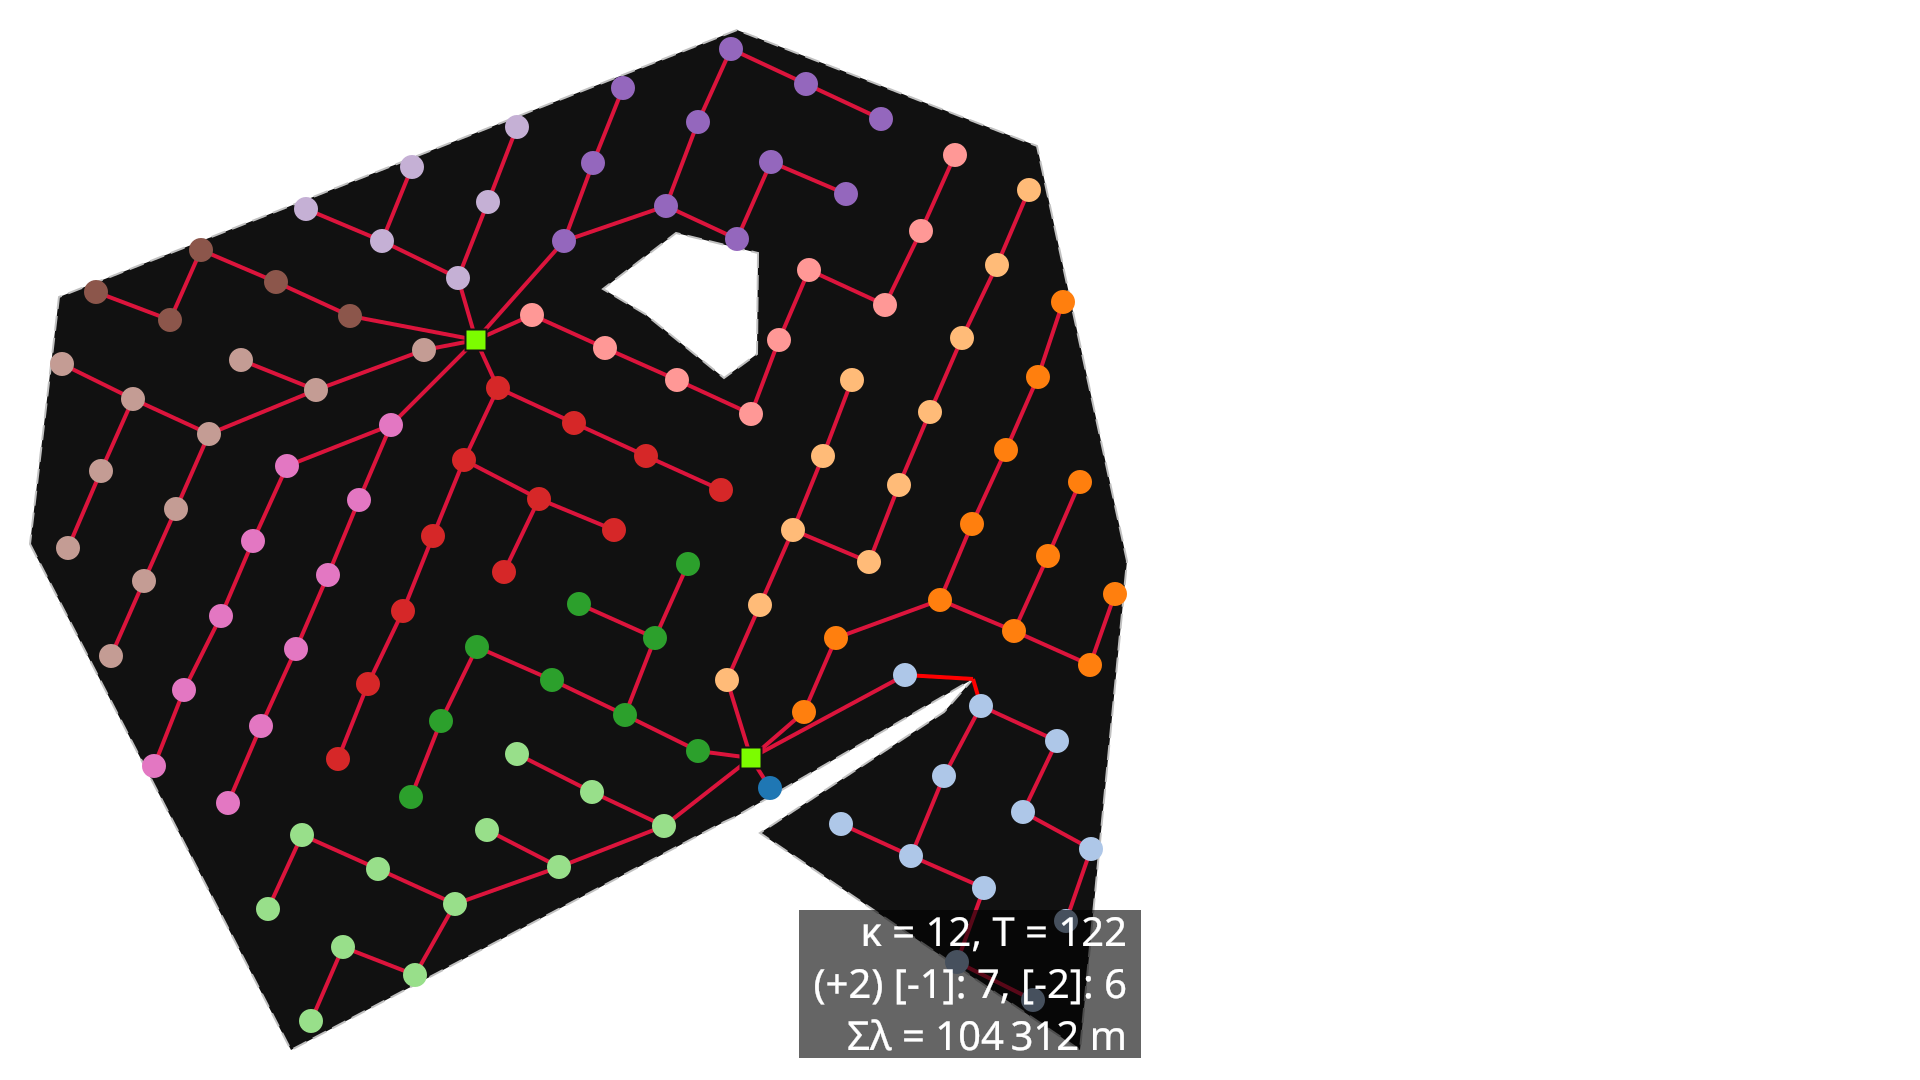

In [5]:
svgplot(G_ref)

### Start here

In [6]:
L = L_from_yaml(files('optiwindnet.data') / 'Taylor-2023.yaml')

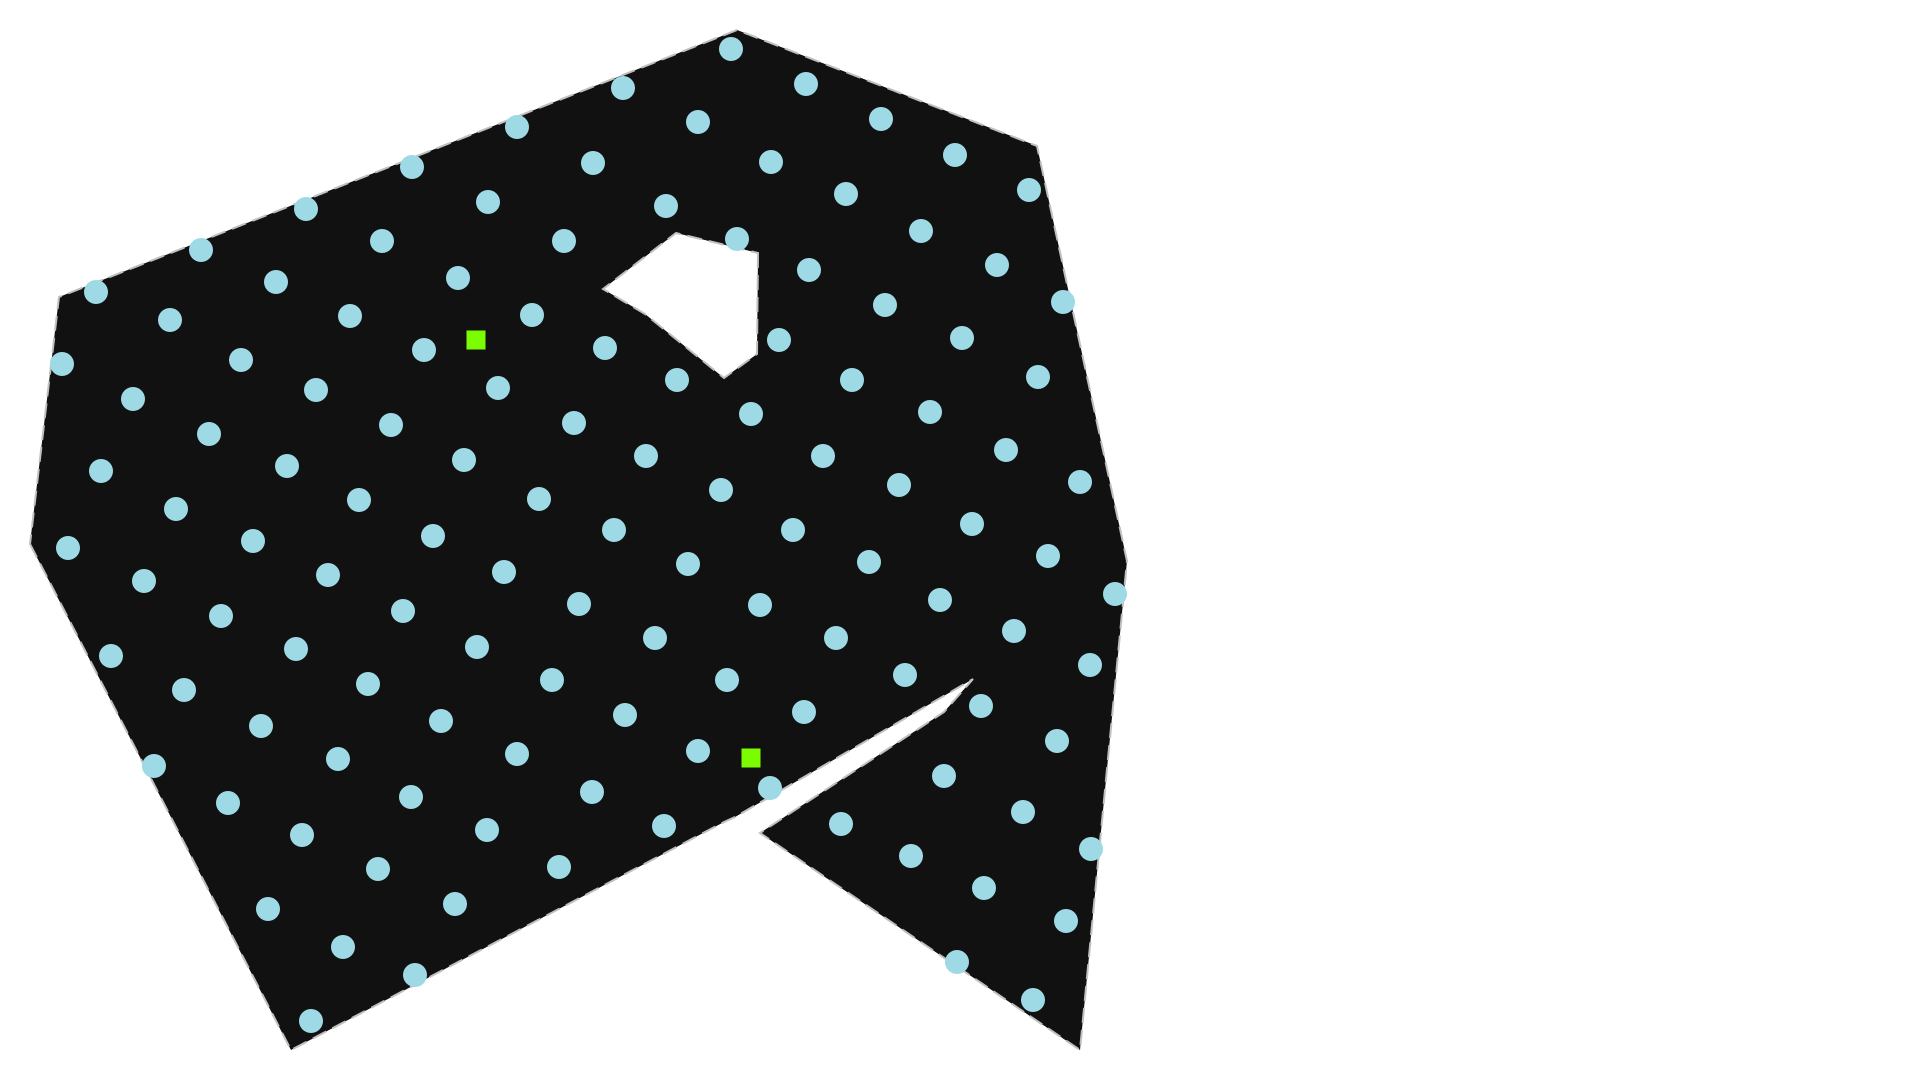

In [7]:
svgplot(L)

In [8]:
P, A = make_planar_embedding(L)

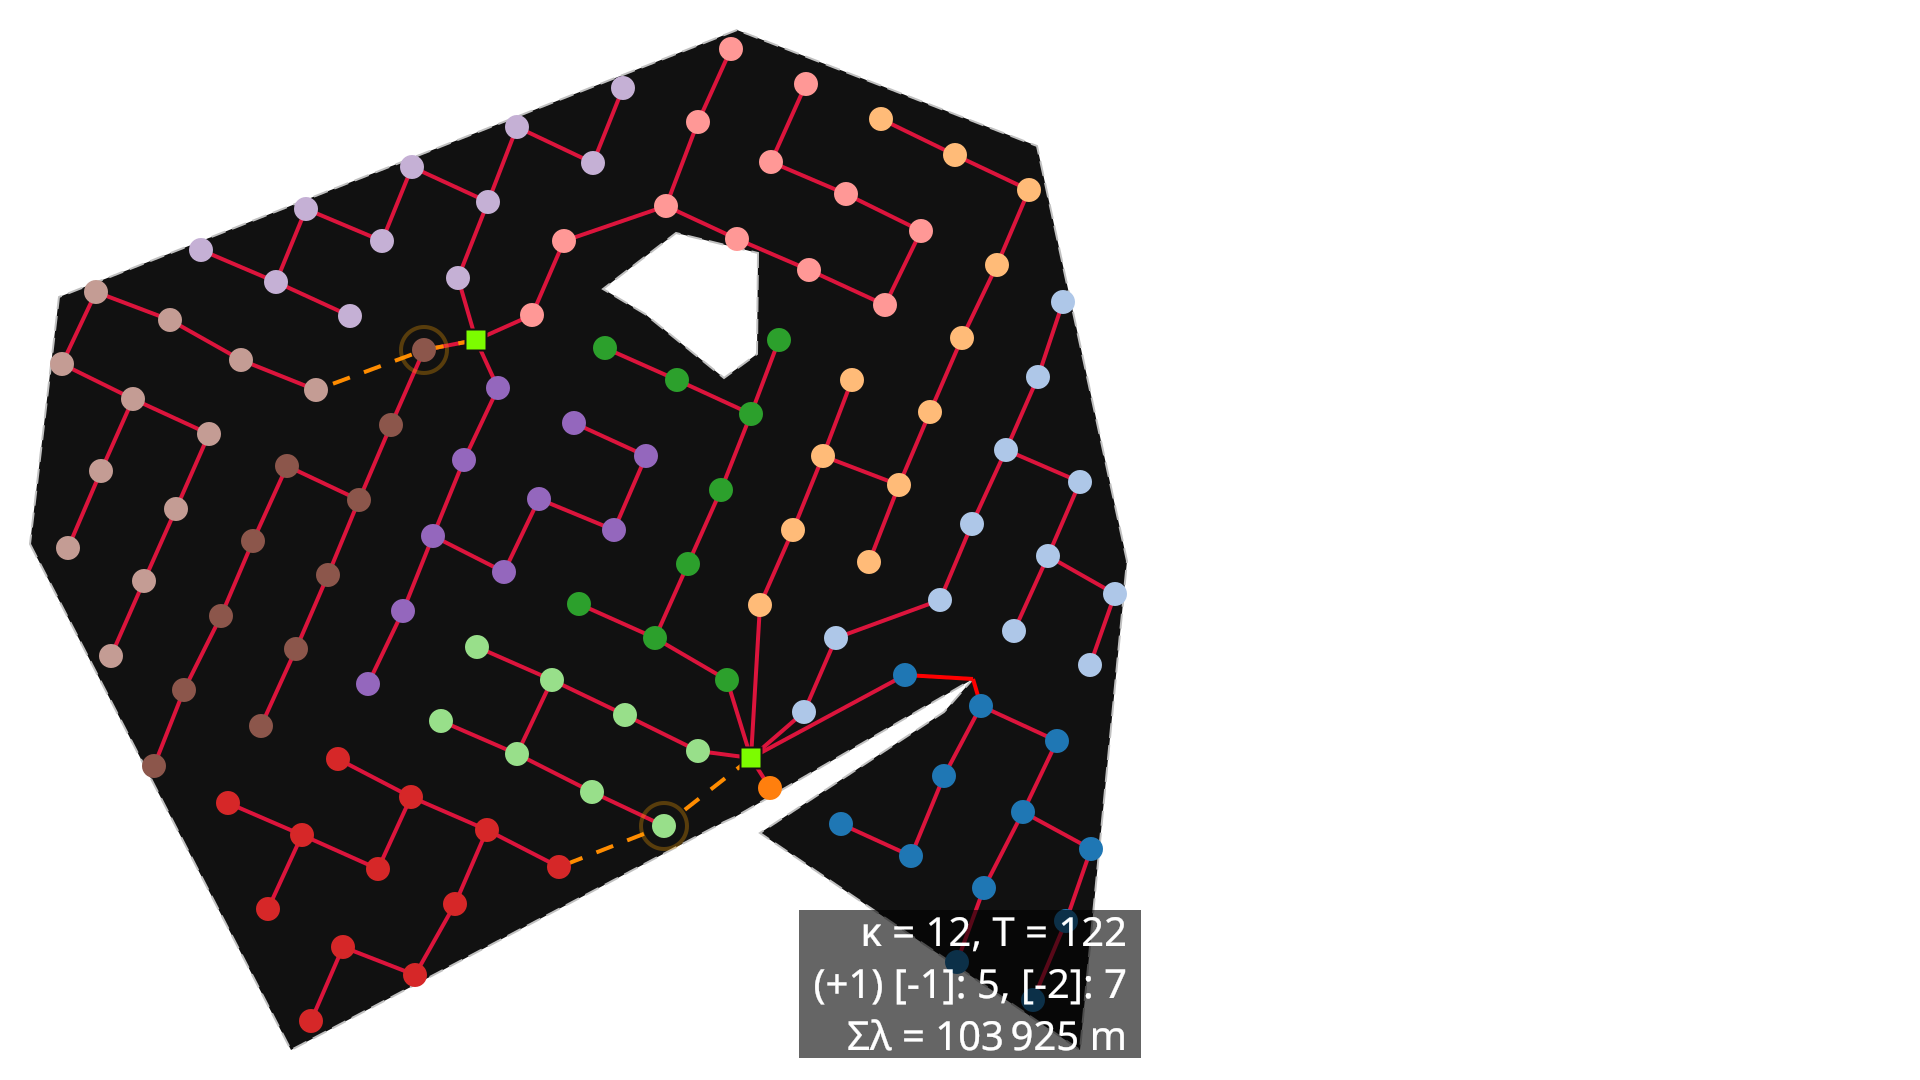

In [9]:
Sʹ = constructor(A, 12)
Gʹ = G_from_S(Sʹ, A)
Hʹ = PathFinder(Gʹ, planar=P, A=A).create_detours()
svgplot(Hʹ)

In [10]:
Sʹ = hgs_cvrp(as_normalized(A), capacity=12, time_limit=0.6)
Sʹ.graph['solution_time']

(0.04, 0.17)

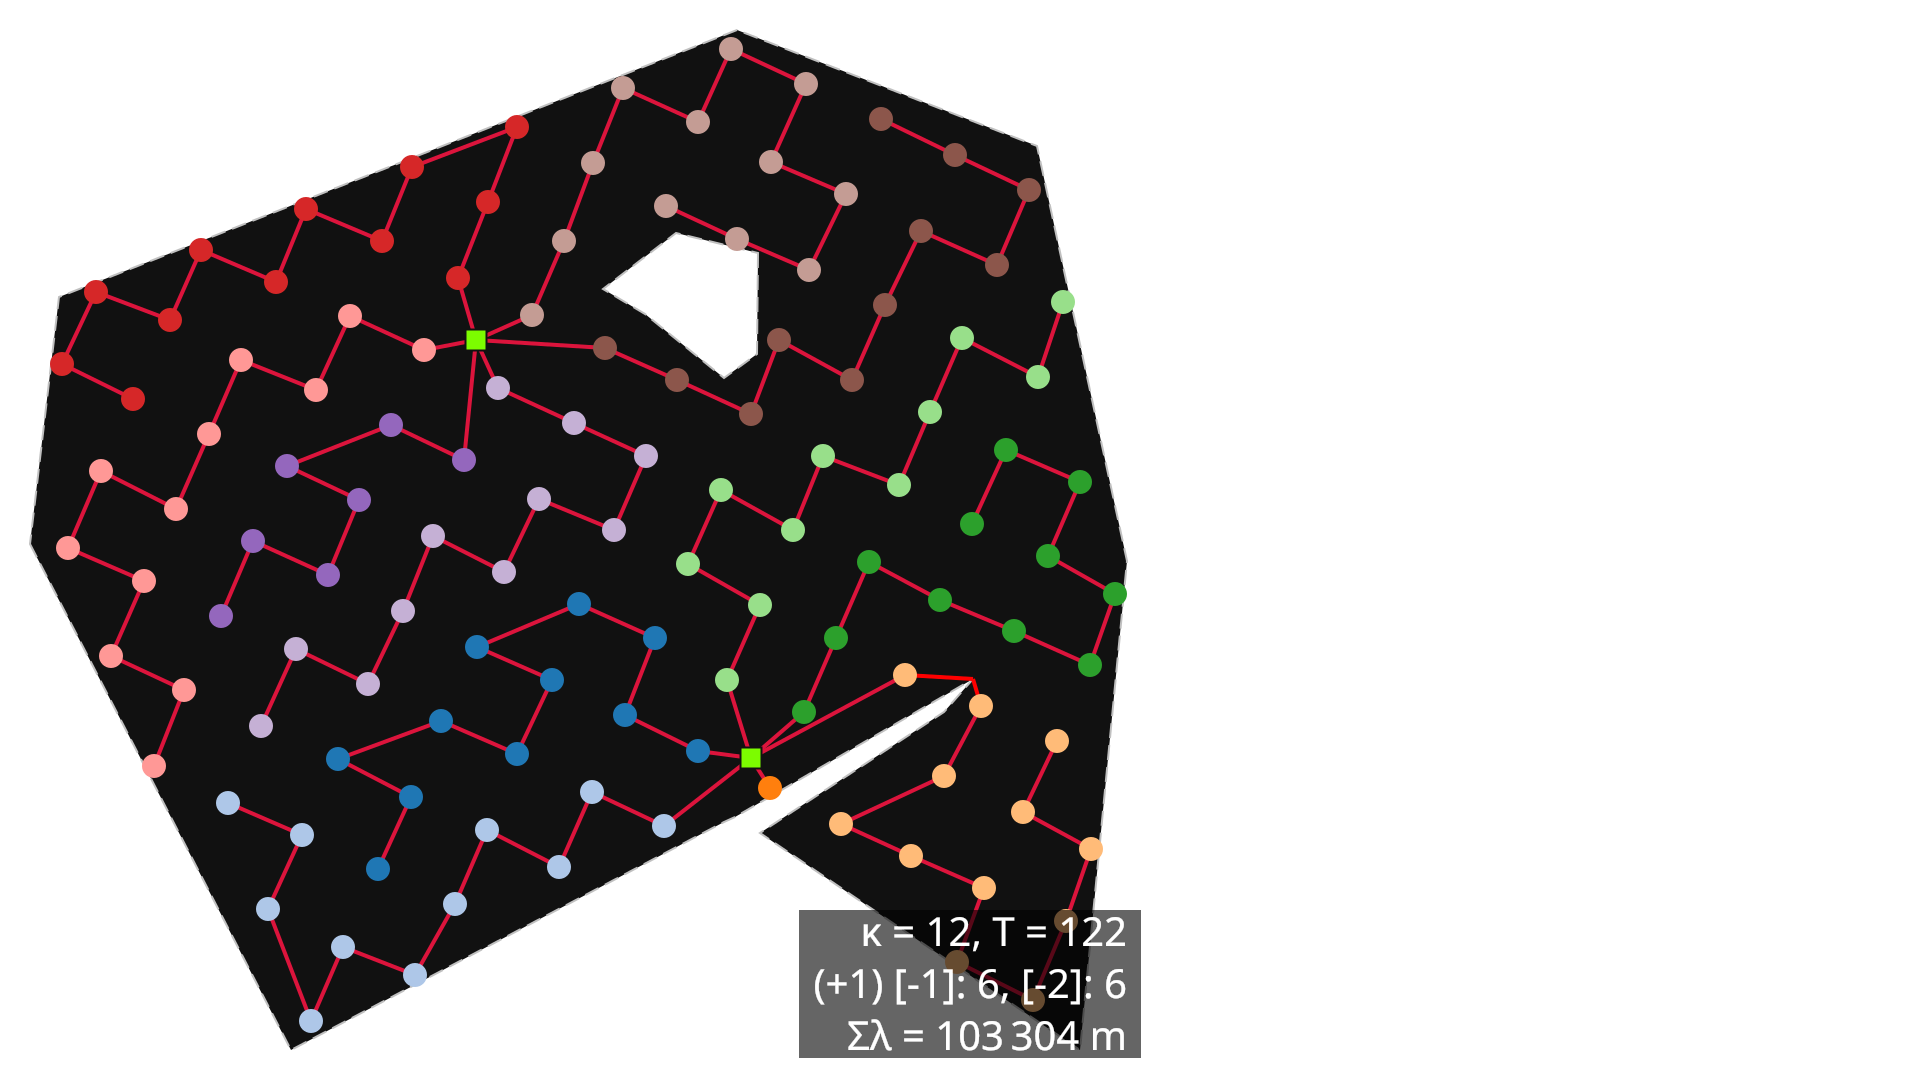

In [11]:
Gʹ = G_from_S(Sʹ, A)
Hʹ = PathFinder(Gʹ, planar=P, A=A).create_detours()
svgplot(Hʹ)

In [12]:
1 - Hʹ.size(weight='length') / G_ref.size(weight='length')

0.009660885114102347

In [13]:
solver.set_problem(
    P,
    A,
    capacity=Sʹ.graph['capacity'],
    model_options=ModelOptions(
        topology='branched',
        feeder_route='segmented',
        feeder_limit='unlimited',
    ),
    warmstart=Sʹ,
)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk


In [14]:
solver.solve(
    mip_gap=0.001,
    time_limit=8,
    verbose=True,
    options={
        'mipfocus': 1,
        'RINS': 100,
        'CutPasses': 4,
        # VarBranch=1,
    },
)

Set parameter RINS to value 100
Set parameter CutPasses to value 4
Set parameter TimeLimit to value 8
Set parameter MIPGap to value 0.001
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Debian GNU/Linux forky/sid")

CPU model: 11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  8
MIPGap  0.001
MIPFocus  1
RINS  100
CutPasses  4

Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Optimize a model with 4316 rows, 2892 columns and 16300 nonzeros (Min)
Model fingerprint: 0x0c04b5a5
Model has 1446 linear objective coefficients
Variable types: 1446 continuous, 1446 integer (1446 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [4e+02, 9e+03]
  Bounds range     [1e+00, 1e+01]
  RHS range        [1e+00, 1e+02]

Loaded user MIP start with objective 103304

Presolve rem

SolutionInfo(runtime=8.015504121780396, bound=100543.13586171626, objective=100778.04543446108, relgap=0.0023309598011362898, termination='maxTimeLimit')

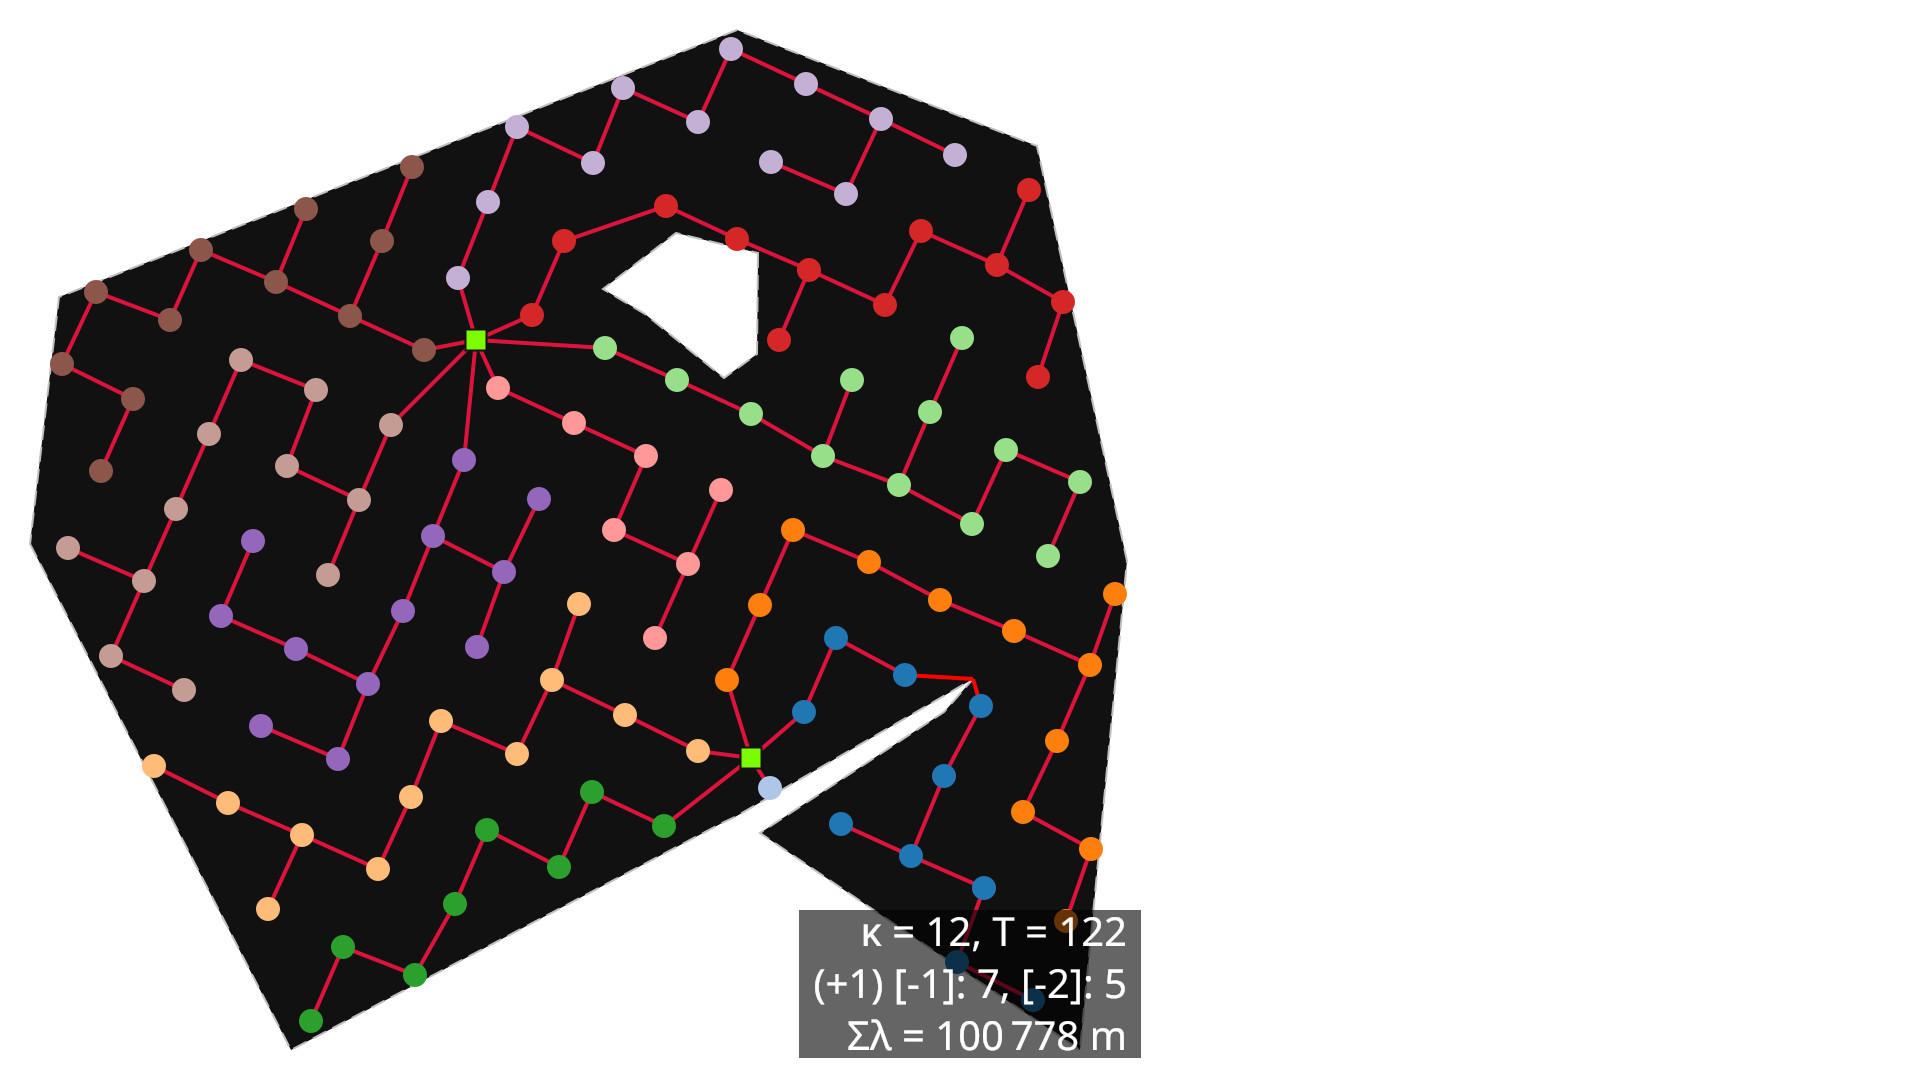

In [15]:
S, G = solver.get_solution()

svgplot(G)

In [16]:
1 - G.size(weight='length') / G_ref.size(weight='length')

0.033879957250474324

In [17]:
with open('Taylor_comparison_κ_12_branched_our.pkl', 'wb') as f:
    pickle.dump(G, f)